# Wave Equation with NumPy

This notebook builds a compact NumPy baseline for the wave equation before introducing NRPy-generated kernels. It evolves a periodic one-dimensional plane wave, makes ghost-zone fills explicit, and measures the expected convergence of a second-order finite-difference discretization.

[Index](../index.ipynb) | Previous: [Reference Metrics](../1-intro/reference_metric.ipynb) | Next: [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb)

## Why This Matters

A NumPy wave solver gives a transparent baseline before code generation. It shows the same first-order system, grid, stencil, time step, and convergence idea in ordinary Python arrays.

## What You Will See

- The first-order scalar wave system in NumPy.
- Periodic ghost-zone fills and RK4 time stepping.
- A convergence table and plot when plotting is available.

## Table of Contents

1. [First-order wave system](#First-order-wave-system)
2. [Grid, ghost zones, and exact solution](#Grid,-ghost-zones,-and-exact-solution)
3. [Right-hand side and RK4 stepper](#Right-hand-side-and-RK4-stepper)
4. [Resolution study](#Resolution-study)
5. [Optional plot](#Optional-plot)
6. [Next notebooks](#Next-notebooks)

## First-order Wave System

The second-order wave equation

$$
\partial_t^2 u = c^2 \partial_x^2 u
$$

becomes a first-order-in-time system after defining $v=\partial_t u$:

$$
\partial_t u = v,\qquad
\partial_t v = c^2 \partial_x^2 u.
$$

The Method of Lines treats the spatial derivative as an ordinary differential equation right-hand side. Here the right-hand side uses a centered second-order stencil. Time integration uses RK4 so that the measured error is dominated by the spatial discretization.

## Grid, Ghost Zones, and Exact Solution

The grid covers $x\in[0,1)$ with cell-centered points. Two ghost zones are enough for the centered Laplacian used below. Periodic ghost fills copy interior values from the opposite side of the domain.

In [1]:
import math

import numpy as np


def exact_solution(x, time, wavespeed=1.0):
    phase = 2.0 * np.pi * (x - wavespeed * time)
    u = np.sin(phase)
    v = -2.0 * np.pi * wavespeed * np.cos(phase)
    return u, v


def grid_points(npoints):
    dx = 1.0 / npoints
    x = (np.arange(npoints) + 0.5) * dx
    return x, dx


def periodic_ghost_array(interior, nghosts=2):
    values = np.empty(interior.size + 2 * nghosts)
    values[nghosts:-nghosts] = interior
    values[:nghosts] = interior[-nghosts:]
    values[-nghosts:] = interior[:nghosts]
    return values


print("NumPy version:", np.__version__)

NumPy version: 2.4.6


## Right-Hand Side and RK4 Stepper

The Courant factor controls the timestep: $\Delta t = C_{\rm CFL}\Delta x/c$. The driver below shortens the final step so the comparison is made exactly at the requested final time.

In [2]:
def wave_rhs(u, v, dx, wavespeed=1.0, nghosts=2):
    u_with_ghosts = periodic_ghost_array(u, nghosts=nghosts)
    center = u_with_ghosts[nghosts:-nghosts]
    left = u_with_ghosts[nghosts - 1 : -nghosts - 1]
    right = u_with_ghosts[nghosts + 1 : -nghosts + 1]
    laplacian_u = (left - 2.0 * center + right) / dx**2
    return v, wavespeed**2 * laplacian_u


def rk4_step(u, v, dt, dx, wavespeed=1.0):
    k1u, k1v = wave_rhs(u, v, dx, wavespeed)
    k2u, k2v = wave_rhs(u + 0.5 * dt * k1u, v + 0.5 * dt * k1v, dx, wavespeed)
    k3u, k3v = wave_rhs(u + 0.5 * dt * k2u, v + 0.5 * dt * k2v, dx, wavespeed)
    k4u, k4v = wave_rhs(u + dt * k3u, v + dt * k3v, dx, wavespeed)

    next_u = u + (dt / 6.0) * (k1u + 2.0 * k2u + 2.0 * k3u + k4u)
    next_v = v + (dt / 6.0) * (k1v + 2.0 * k2v + 2.0 * k3v + k4v)
    return next_u, next_v


def evolve(npoints, final_time=0.2, wavespeed=1.0, courant_factor=0.25):
    x, dx = grid_points(npoints)
    u, v = exact_solution(x, 0.0, wavespeed)
    time = 0.0
    nominal_dt = courant_factor * dx / wavespeed

    while time < final_time:
        dt = min(nominal_dt, final_time - time)
        u, v = rk4_step(u, v, dt, dx, wavespeed)
        time += dt

    exact_u, exact_v = exact_solution(x, final_time, wavespeed)
    l2_u = math.sqrt(dx * np.sum((u - exact_u) ** 2))
    l2_v = math.sqrt(dx * np.sum((v - exact_v) ** 2))
    return {
        "npoints": npoints,
        "dx": dx,
        "x": x,
        "u": u,
        "v": v,
        "exact_u": exact_u,
        "exact_v": exact_v,
        "l2_u": l2_u,
        "l2_v": l2_v,
    }


sample = evolve(64)
print(f"N={sample['npoints']}, dx={sample['dx']:.6f}, L2(u)={sample['l2_u']:.6e}")

N=64, dx=0.015625, L2(u)=3.750446e-04


## Resolution Study

Refining the grid by a factor of two should reduce the $u$ error by approximately four because the spatial Laplacian is second-order accurate.

In [3]:
resolutions = [64, 128, 256]
results = [evolve(npoints) for npoints in resolutions]

print(" npoints        dx          L2(u)      factor      L2(v)")
previous = None
for result in results:
    factor = ""
    if previous is not None:
        factor = f"{previous['l2_u'] / result['l2_u']:.3f}"
    print(
        f"{result['npoints']:8d}  {result['dx']:.6e}  "
        f"{result['l2_u']:.6e}  {factor:>8}  {result['l2_v']:.6e}"
    )
    previous = result

 npoints        dx          L2(u)      factor      L2(v)
      64  1.562500e-02  3.750446e-04            3.202544e-03
     128  7.812500e-03  9.377571e-05     3.999  8.006910e-04
     256  3.906250e-03  2.344484e-05     4.000  2.001762e-04


## Optional Plot

Plotting is useful for visual inspection but is not required for the convergence measurement. If Matplotlib is unavailable, the table above is the complete result.

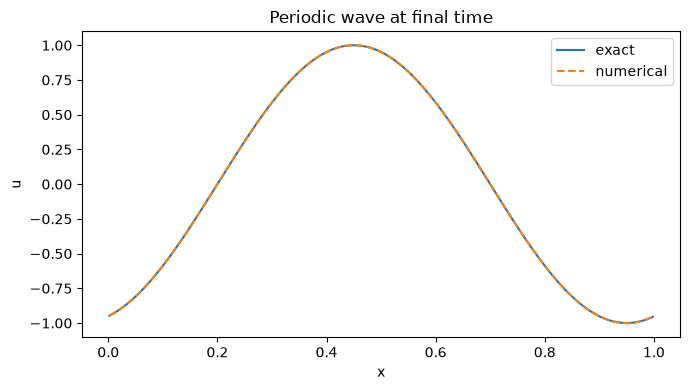

In [4]:
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    print(f"Plotting unavailable: {type(exc).__name__}: {exc}")
else:
    finest = results[-1]
    plt.figure(figsize=(7, 4))
    plt.plot(finest["x"], finest["exact_u"], label="exact")
    plt.plot(finest["x"], finest["u"], "--", label="numerical")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("Periodic wave at final time")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Next Notebooks

The same split between spatial right-hand sides and time stepping appears in [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb). The finite-difference stencil logic is expanded in [Finite-difference playground](finite_difference_playground.ipynb), then connected to generated wave-equation code in [Wave equation and C code generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb).

## Where This Leads

- [Reference Metrics](../1-intro/reference_metric.ipynb) reviews the prerequisite step.
- [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb) continues the tutorial path.
- [Index](../index.ipynb) returns to the full tutorial spine.